# Алгоритм импульсного накопительного счётчика весов
## Зачем
Директор фабрики дал указание скорректировать накопительный счётчик весов 12 конвейера на 17% в минус.
## Почему
Оригинальный счётчик весов 12 конвейера  добавляет в аккумулятор (DINT) 1 т по каждому дискретному импульсу от весов.
Попытка перевести аккумулятор в REAL и добавлять по 0,83т каждый импульс выявило проблему вещественных чисел с плавающей точкой - нельзя складывать числа отличающиеся м\у собой на много порядков. В данном случае (`45000000.0 + 0,8 = 45000000.0`) приводила к тому что в итоговое число ничего не добавлялось.
(Ябучая магия IEEE 754 ``0,2 + 0,2 != 0.4``).

Тогда был разработан алгоритм коррекции накопительного веса на основании пропуска-добавления импульсов.

- 100 импульсов = 100т.
- -10% игнорирование каждого 10 импульса.
## Как
### Корректировка  -17% 
- -17% игнорирование каждого 6 (100 / 17% = 5,88 -> округляем до 6 (16.66%)) 
- но накапливается ошибка в 0.33% (17% - 16.66% = 0.33% или +3.4 кг на каждый импульс/тонну )
- что бы компенсировать ошибку алгоритм накапливает её до 1т, для этого 100 / 0.33 = 303  (игнорируется каждый 303 импульс)
### Корректировка +17% 
- 17% добавление каждый 6 импульс + 1т (100 / 17% = 5,88 -> округляем до 6 (16.66%)) 
- но накапливается ошибка в 0.34% (17% - 16.66% = 0.34% или -3.4 кг на каждый импульс/тонну )
- что бы компенсировать ошибку алгоритм накапливает её до 1т, для этого 100 / 0.34 = 303  (добавляется 1 т на каждый 304 импульс)
### Корректировка -16% 
- -16% игнорирование каждого 6 (100 / 16% = 6,25 -> округляем до 6 (16.66%)) 
- но накапливается ошибка в 0.66% (16% - 16.66% = -0.66% или -6.6 кг на каждый импульс/тонну )
- что бы компенсировать ошибку алгоритм накапливает её до 1т, для этого 100 / 0.66 = 151  (добавляется 1 т на каждый 151 импульс)
### Корректировка +16% 
- +16% добавление каждый 6 импульс + 1т (100 / 16% = 6,25 -> округляем до 6 (16.66%)) 
- но накапливается ошибка в 0.66% (16% - 16.66% = -0.66% или +6.6 кг на каждый импульс/тонну )
- что бы компенсировать ошибку алгоритм накапливает её до 1т, для этого 100 / 0.66 = 151   (игнорируется каждый 151 импульс)ся кign} импульс.етк 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from ipywidgets import interact, interact_manual
from plotly.graph_objs import *

sns.set(style="darkgrid")
pd.set_option("display.max_columns", None)

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


In [2]:
def tot_plus(k=0.0, qty_imp=1000, comp=True):
    """"""
    ratio = k
    weight_acc = 0
    cnt_main = 0
    cnt_err = 0
    corr_on = True if ratio != 0 else False  # включение корректировки веса
    corr_decr = True if ratio < 0 else False  # корректировка в сторону уменьшения
    ratio = abs(ratio)
    if corr_on:
        parts = 100 / ratio  # какой импульс обработать
        parts_round = round(parts)  # какой импульс обработать, округлён до целого
        parts_fract = parts % 1
        # если есть дробная часть и округление то необходима компенсация
        compensat_on = True if parts_fract != 0 else False  # комп-ция округления
        if compensat_on:
            # Если округление к большему проценту то корректируем на уменьшение
            # и наоборот
            ratio_round = 100 / parts_round
            ratio_err = ratio - ratio_round
            parts_err = round(100 / abs(ratio_err))
            if corr_decr:  # корректируем на уменьшение
                round_down = True if ratio_err > 0 else False
            else:  # на увеличение
                round_down = True if ratio_err < 0 else False
            # parts_err = 100 / abs(ratio_err)
    # Перебор в цикле импульсов
    for i in range(qty_imp):
        if corr_on:
            cnt_main += 1
            cnt_err += 1
            if cnt_main >= parts_round:
                cnt_main = 0
                if corr_decr:
                    continue
                else:
                    weight_acc += 1
            # компенсация округления
            if compensat_on and cnt_err >= parts_err and comp:
                cnt_err = 0
                # если процент округлён в меньшую сторону то пропускаем
                # если в большую до добавляем
                if round_down:
                    continue
                else:
                    weight_acc += 1

        weight_acc += 1
    return weight_acc

In [3]:
@interact(k=(-50, 50, 1))
def w_calc(k=0):
    weight = tot_plus(k, 1000)
    print(weight)
    print(weight / 1000 * 100 - 100)

interactive(children=(IntSlider(value=0, description='k', max=50, min=-50), Output()), _dom_classes=('widget-i…

In [4]:
qty_iter = 1000  # колличество итераций
data = []
for i in range(-20, 20):
    weight = tot_plus(i, qty_iter, comp=True)
    data.append([i, weight / qty_iter * 100 - 100, weight])

df = pd.DataFrame(data, columns=["k", "%", "val"])

df.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39
k,-20.0,-19.0,-18.0,-17.0,-16.0,-15.0,-14.0,-13.0,-12.0,-11.0,-10.0,-9.0,-8.0,-7.0,-6.0,-5.0,-4.0,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0
%,-20.0,-19.1,-17.9,-16.9,-16.0,-14.9,-14.0,-12.9,-12.1,-11.0,-10.0,-9.0,-8.0,-7.0,-5.9,-5.0,-4.0,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,5.9,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,14.9,16.0,16.9,17.9,19.0
val,800.0,809.0,821.0,831.0,840.0,851.0,860.0,871.0,879.0,890.0,900.0,910.0,920.0,930.0,941.0,950.0,960.0,970.0,980.0,990.0,1000.0,1010.0,1020.0,1030.0,1040.0,1050.0,1059.0,1070.0,1080.0,1090.0,1100.0,1110.0,1120.0,1130.0,1140.0,1149.0,1160.0,1169.0,1179.0,1190.0


<Axes: >

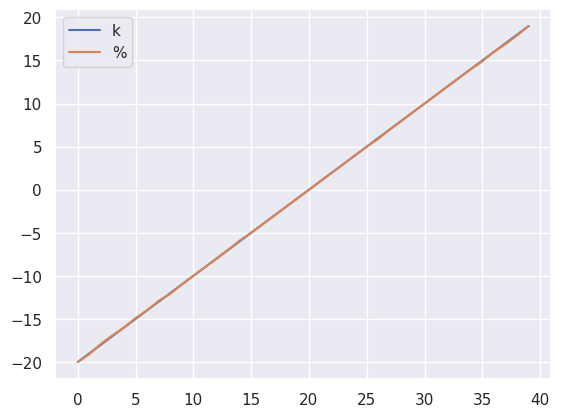

In [5]:
df[["k", "%"]].plot(use_index=True)